# Predicting Rainfall in Melbourne with Machine Learning

## Project overview
This project uses historical weather observations to predict the
probability of rain on the following day in the Melbourne area.

## Objectives
- Explore the dataset and assess its quality.
- Prepare numerical and categorical features.
- Train and compare classification models.
- Evaluate predictions on unseen data.
- Explain the results and limitations.

## Acknowledgment
This project builds on the final assignment from IBM’s
Machine Learning with Python course on Coursera.




## 1. Load and inspect the dataset

### Purpose
Load the historical Australian weather dataset supplied in the
IBM assignment and examine its structure before making changes.

### Approach
- Preserve the original data in `df_raw`.
- Record the source URL and initial row and column counts.
- Inspect column types, missing values, and available locations.

The dataset covers multiple Australian locations. We will select
the Melbourne area in the next step.

In [20]:
# Import tools for data analysis and visualization.
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Apply a consistent style to the project's charts.
sns.set_theme(style="whitegrid")

In [21]:
# Source supplied in the IBM Machine Learning with Python assignment.
DATA_URL = (
    "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/"
    "_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv"
)

# Preserve this table as the original data; use copies for transformations.
df_raw = pd.read_csv(DATA_URL)

# Record the source and initial dimensions for later comparisons.
print(f"Source: {DATA_URL}")
print(f"Original rows: {df_raw.shape[0]:,}")
print(f"Original columns: {df_raw.shape[1]}")

# Preview observations to check how the data is organized.
display(df_raw.head())

Source: https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/_0eYOqji3unP1tDNKWZMjg/weatherAUS-2.csv
Original rows: 145,460
Original columns: 23


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


## 2. Select the study area

We focus on Melbourne, Melbourne Airport, and Watsonia,
following the geographic scope of the IBM assignment.

We retain `Location` because weather conditions may differ
between stations. We record the row counts before and after
selection to document the change in scope.

In [22]:
# Define the three locations included in our study.
STUDY_LOCATIONS = ["Melbourne", "MelbourneAirport", "Watsonia"]

# Create an independent working table, preserving the original data.
df = df_raw.loc[
    df_raw["Location"].isin(STUDY_LOCATIONS)
].copy()

# Record how geographic selection changes the dataset size.
print(f"Original rows: {len(df_raw):,}")
print(f"Selected rows: {len(df):,}")
print(f"Rows outside the study area: {len(df_raw) - len(df):,}")

# Check the number of observations available for each station.
station_counts = (
    df.groupby("Location")
      .size()
      .rename("Observations")
      .to_frame()
)

display(station_counts)

Original rows: 145,460
Selected rows: 9,211
Rows outside the study area: 136,249


,Observations
Location,
Melbourne,3193
MelbourneAirport,3009
Watsonia,3009


## 3. Assess data quality in the study area

Before cleaning the data, we inspect:
- Missing values in each column.
- The date range and any missing or invalid dates.
- Exact duplicate rows and repeated location–date combinations.

These checks will guide our preparation decisions.
No observations are removed at this stage.

In [23]:
# Measure missing values specifically within our selected study area.
regional_missing = pd.DataFrame({
    "Missing count": df.isna().sum(),
    "Missing (%)": df.isna().mean().mul(100).round(2)
}).sort_values("Missing count", ascending=False)

display(regional_missing)

# Identify observations without a known prediction target.
missing_targets = df["RainTomorrow"].isna().sum()

print(f"Observations with missing target: {missing_targets:,}")

,Missing count,Missing (%)
Cloud3pm,1108,12.03
Cloud9am,1034,11.23
Rainfall,768,8.34
RainToday,768,8.34
RainTomorrow,768,8.34
Humidity9am,504,5.47
Humidity3pm,496,5.38
Temp9am,495,5.37
MinTemp,487,5.29
Temp3pm,484,5.25


Observations with missing target: 768


In [24]:
# Parse dates separately so the working table remains unchanged.
# Missing or unparseable dates become NaT (Not a Time).
parsed_dates = pd.to_datetime(
    df["Date"],
    format="%Y-%m-%d",
    errors="coerce"
)

print(f"First observation date: {parsed_dates.min()}")
print(f"Last observation date: {parsed_dates.max()}")
print(f"Missing or invalid dates: {parsed_dates.isna().sum():,}")

# Count repeated full rows beyond their first occurrence.
exact_duplicates = df.duplicated().sum()
print(f"Extra exact duplicate rows: {exact_duplicates:,}")

# Flag all rows sharing a location–date combination.
repeated_keys = df.duplicated(
    subset=["Location", "Date"],
    keep=False
)

print(f"Rows with repeated location–date keys: {repeated_keys.sum():,}")

# Display flagged records for inspection before deciding what to do.
if repeated_keys.any():
    display(
        df.loc[repeated_keys]
          .sort_values(["Location", "Date"])
          .head(10)
    )

First observation date: 2008-07-01 00:00:00
Last observation date: 2017-06-25 00:00:00
Missing or invalid dates: 0
Extra exact duplicate rows: 0
Rows with repeated location–date keys: 0


## 4. Prepare usable records

We require:
- A known `RainTomorrow` outcome for training and evaluation.
- A valid observation date for chronological splitting.

We preserve excluded records with flags explaining each exclusion.
Missing weather measurements remain available for later preprocessing.

Exact duplicate rows are counted and reduced to one occurrence.
Repeated location–date keys with different data require inspection.

In [25]:
# Check that known target labels match the expected categories.
known_labels = set(df["RainTomorrow"].dropna().unique())

if not known_labels.issubset({"Yes", "No"}):
    raise ValueError(f"Unexpected target labels: {known_labels}")

# Parse dates while preserving the original values in df.
parsed_dates = pd.to_datetime(
    df["Date"],
    format="%Y-%m-%d",
    errors="coerce"
)

# Identify why an observation cannot be used.
missing_target = df["RainTomorrow"].isna()
unusable_date = parsed_dates.isna()
exclude_mask = missing_target | unusable_date

# Preserve excluded records and both reasons, which may overlap.
excluded_unusable = df.loc[exclude_mask].copy()
excluded_unusable["MissingTarget"] = missing_target.loc[exclude_mask]
excluded_unusable["UnusableDate"] = unusable_date.loc[exclude_mask]

# Create the usable dataset and store dates as datetime values.
df_clean = df.loc[~exclude_mask].copy()
df_clean["Date"] = parsed_dates.loc[~exclude_mask]

print(f"Rows before preparation: {len(df):,}")
print(f"Rows excluded for target/date issues: {len(excluded_unusable):,}")
print(f"Rows remaining: {len(df_clean):,}")

display(excluded_unusable.head())

Rows before preparation: 9,211
Rows excluded for target/date issues: 768
Rows remaining: 8,443


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,MissingTarget,UnusableDate
68148,2011-02-04,Melbourne,18.2,30.4,2.4,4.0,1.6,N,54.0,N,...,1010.1,1007.3,7.0,7.0,24.0,26.2,Yes,NaN,True,False
68149,2011-02-05,Melbourne,18.1,20.3,NaN,7.6,0.0,WSW,54.0,SW,...,1006.1,1006.9,NaN,NaN,18.4,19.0,NaN,NaN,True,False
68155,2011-02-11,Melbourne,20.9,25.8,1.8,6.0,0.2,N,46.0,NNW,...,1010.2,1010.0,7.0,8.0,23.2,21.0,Yes,NaN,True,False
68156,2011-02-12,Melbourne,15.4,21.1,NaN,10.4,8.8,SSE,41.0,SSE,...,1020.5,1019.6,NaN,NaN,15.6,20.1,NaN,NaN,True,False
68162,2011-02-18,Melbourne,19.3,29.4,0.0,3.8,3.3,SSW,24.0,W,...,1014.6,1010.5,8.0,7.0,21.3,28.6,No,NaN,True,False


In [26]:
# Flag extra identical rows, keeping their first occurrence.
duplicate_mask = df_clean.duplicated(keep="first")

# Preserve the excluded copies for traceability.
excluded_duplicates = df_clean.loc[duplicate_mask].copy()

# Keep one occurrence of each identical observation.
df_clean = df_clean.loc[~duplicate_mask].copy()

print(f"Exact duplicate rows excluded: {len(excluded_duplicates):,}")
print(f"Prepared rows: {len(df_clean):,}")

# Different records for the same station and date need investigation.
repeated_keys = df_clean.duplicated(
    subset=["Location", "Date"],
    keep=False
)

if repeated_keys.any():
    display(
        df_clean.loc[repeated_keys]
        .sort_values(["Location", "Date"])
    )
    raise ValueError(
        "Repeated location–date keys remain. Inspect them before splitting."
    )

Exact duplicate rows excluded: 0
Prepared rows: 8,443


## 5. Create a chronological train–test split

We reserve approximately the latest 20% of distinct observation
dates for testing and use earlier dates for training.

All observations from the same date remain in the same partition.

We exclude boundary observations whose next-day target reaches
the test period. These records are preserved separately.

The test set will remain reserved during feature selection,
preprocessing fitting, and model tuning.

In [27]:
# Sort distinct observation dates to choose a chronological boundary.
observation_dates = (
    df_clean["Date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

if len(observation_dates) < 2:
    raise ValueError("At least two distinct dates are required.")

# Reserve approximately the latest 20% of observed dates for testing.
split_position = int(len(observation_dates) * 0.80)
test_start_date = observation_dates.iloc[split_position]

# Each label describes the day following its observation.
target_dates = df_clean["Date"] + pd.Timedelta(days=1)

# Training outcomes must occur before the test observation period.
train_mask = target_dates < test_start_date
test_mask = df_clean["Date"] >= test_start_date

# Preserve boundary records that belong to neither partition.
buffer_mask = ~(train_mask | test_mask)

train_df = (
    df_clean.loc[train_mask]
    .sort_values(["Date", "Location"])
    .copy()
)

test_df = (
    df_clean.loc[test_mask]
    .sort_values(["Date", "Location"])
    .copy()
)

split_buffer = df_clean.loc[buffer_mask].copy()

if train_df.empty or test_df.empty:
    raise ValueError("The split produced an empty training or test set.")

In [28]:
# Document the actual sizes and date ranges without examining test outcomes.
split_summary = pd.DataFrame({
    "Partition": ["Training", "Boundary buffer", "Test"],
    "Rows": [len(train_df), len(split_buffer), len(test_df)],
    "First observation": [
        train_df["Date"].min(),
        split_buffer["Date"].min(),
        test_df["Date"].min()
    ],
    "Last observation": [
        train_df["Date"].max(),
        split_buffer["Date"].max(),
        test_df["Date"].max()
    ]
})

print(f"Test period starts: {test_start_date.date()}")
display(split_summary)

Test period starts: 2015-09-26


,Partition,Rows,First observation,Last observation
0,Training,6749,2008-07-01,2015-09-24
1,Boundary buffer,2,2015-09-25,2015-09-25
2,Test,1692,2015-09-26,2017-06-25


## 6. Explore the training data and create a seasonal feature

We examine:
- The distribution of rain and no-rain outcomes.
- The percentage of observations followed by rain in each season.

We derive `Season` from the observation month using Southern
Hemisphere meteorological seasons.

The same fixed transformation is applied to training and test
inputs. Test outcomes remain reserved for final evaluation.

Observed associations describe this dataset; they do not
establish causation.

,Observations,Percentage
RainTomorrow,,
No,5123,75.91
Yes,1626,24.09


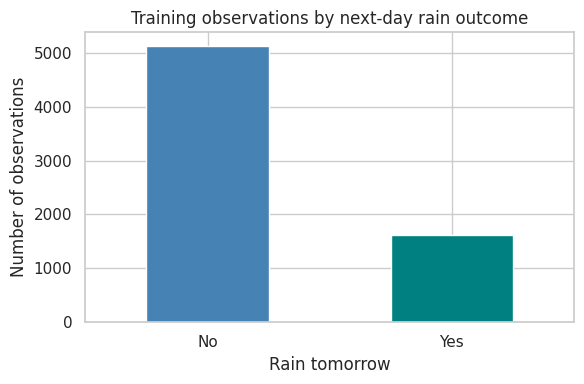

In [29]:
# Count both target categories in the training data.
class_counts = (
    train_df["RainTomorrow"]
    .value_counts()
    .reindex(["No", "Yes"], fill_value=0)
)

# Express the counts as percentages of training observations.
class_summary = class_counts.to_frame("Observations")
class_summary["Percentage"] = (
    class_counts / class_counts.sum() * 100
).round(2)

display(class_summary)

# Visualize how frequently each outcome occurs.
ax = class_counts.plot.bar(
    figsize=(6, 4),
    color=["steelblue", "teal"],
    rot=0
)

ax.set_title("Training observations by next-day rain outcome")
ax.set_xlabel("Rain tomorrow")
ax.set_ylabel("Number of observations")
plt.tight_layout()
plt.show()

In [30]:
# Map months to Southern Hemisphere meteorological seasons.
MONTH_TO_SEASON = {
    12: "Summer", 1: "Summer", 2: "Summer",
    3: "Autumn", 4: "Autumn", 5: "Autumn",
    6: "Winter", 7: "Winter", 8: "Winter",
    9: "Spring", 10: "Spring", 11: "Spring"
}

def add_season(data):
    # Work on a copy to preserve the function's input table.
    result = data.copy()

    # Extract the month and replace it with its season name.
    result["Season"] = result["Date"].dt.month.map(MONTH_TO_SEASON)

    return result

# Apply the same predefined rule to both partitions.
train_df = add_season(train_df)
test_df = add_season(test_df)

# Preview training inputs to check the transformation.
display(train_df[["Date", "Location", "Season"]].head())

,Date,Location,Season
67200,2008-07-01,Melbourne,Winter
67201,2008-07-02,Melbourne,Winter
67202,2008-07-03,Melbourne,Winter
67203,2008-07-04,Melbourne,Winter
67204,2008-07-05,Melbourne,Winter


,Rain tomorrow (%)
Season,
Summer,16.742081
Autumn,22.097156
Winter,29.249448
Spring,27.262045


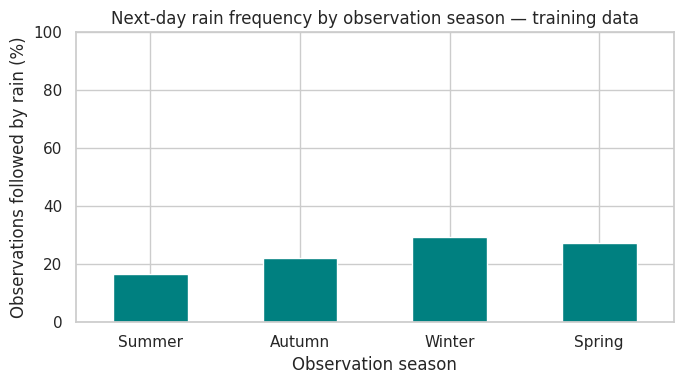

In [31]:
# True represents a rain outcome; False represents no rain.
rain_flag = train_df["RainTomorrow"].eq("Yes")

# The mean of Boolean values gives the proportion of True values.
rain_by_season = (
    rain_flag.groupby(train_df["Season"])
    .mean()
    .mul(100)
    .reindex(["Summer", "Autumn", "Winter", "Spring"])
)

display(rain_by_season.rename("Rain tomorrow (%)").to_frame())

# Compare next-day rain percentages across observation seasons.
ax = rain_by_season.plot.bar(
    figsize=(7, 4),
    color="teal",
    rot=0
)

ax.set_title("Next-day rain frequency by observation season — training data")
ax.set_xlabel("Observation season")
ax.set_ylabel("Observations followed by rain (%)")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## 7. Define inputs, preprocessing, and a baseline

We separate the input features (`X`) from the target (`y`):
- `0`: no rain tomorrow.
- `1`: rain tomorrow.

We exclude the raw date from the model inputs and retain Season.

Preprocessing will:
- Fill missing numerical values with training medians.
- Standardize numerical features.
- Represent missing categorical values as "Missing".
- One-hot encode categorical features.

Preprocessing will be fitted inside each model pipeline during
training and validation. Test data will use the learned transformations.

A majority-class baseline provides a simple comparison.

In [32]:
# Remove the answer and raw date from the input features.
# Date remains available in train_df and test_df for temporal checks.
X_train = train_df.drop(columns=["RainTomorrow", "Date"]).copy()
X_test = test_df.drop(columns=["RainTomorrow", "Date"]).copy()

# Encode the target consistently: No = 0, Yes = 1.
TARGET_MAPPING = {"No": 0, "Yes": 1}

y_train = train_df["RainTomorrow"].map(TARGET_MAPPING)
y_test = test_df["RainTomorrow"].map(TARGET_MAPPING)

# Identify feature types using the training inputs.
numeric_features = (
    X_train.select_dtypes(include="number").columns.tolist()
)

categorical_features = (
    X_train.select_dtypes(
        include=["object", "category", "string"]
    ).columns.tolist()
)

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)
print(f"Training input shape: {X_train.shape}")
print(f"Test input shape: {X_test.shape}")

Numerical features: ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am', 'Temp3pm']
Categorical features: ['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday', 'Season']
Training input shape: (6749, 22)
Test input shape: (1692, 22)


In [33]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical features: fill missing values, then standardize.
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="median",
        keep_empty_features=True
    )),
    ("scaler", StandardScaler())
])

# Categorical features: preserve missingness as a separate category,
# then convert categories into numerical indicator columns.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(
        strategy="constant",
        fill_value="Missing",
        keep_empty_features=True
    )),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Apply the appropriate transformations to each feature group.
preprocessor = ColumnTransformer(transformers=[
    ("numeric", numeric_transformer, numeric_features),
    ("categorical", categorical_transformer, categorical_features)
])

In [34]:
from sklearn.dummy import DummyClassifier

# Learn which target category is most common in the training data.
baseline = DummyClassifier(strategy="most_frequent")
baseline.fit(X_train, y_train)

# Inspect its constant prediction without evaluating the test set.
baseline_prediction = int(
    baseline.predict(X_train.iloc[[0]])[0]
)

LABEL_NAMES = {0: "No rain", 1: "Rain"}

print(
    "The baseline always predicts:",
    LABEL_NAMES[baseline_prediction]
)

The baseline always predicts: No rain


## 8. Train and tune classification models

We compare logistic regression and Random Forest using three
chronological validation folds within the training period.

Each fold:
- Trains on earlier dates and validates on later dates.
- Keeps observations from the same date together.
- Excludes training records whose next-day outcomes reach validation.

Preprocessing is fitted separately within each fold.

We select model settings using mean validation average precision.
We also report F1 and accuracy. The final test set remains reserved.

In [35]:
import numpy as np
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

# Confirm that row positions still match our model inputs and labels.
if not (
    X_train.index.equals(train_df.index)
    and y_train.index.equals(train_df.index)
):
    raise ValueError("Training rows are misaligned. Rerun step 7.")

# Build an ordered list of dates within the training period.
training_dates = (
    train_df["Date"]
    .drop_duplicates()
    .sort_values()
    .reset_index(drop=True)
)

if len(training_dates) < 4:
    raise ValueError("More training dates are needed for three folds.")

date_splitter = TimeSeriesSplit(n_splits=3)
cv_splits = []
fold_records = []

for fold, (earlier_positions, later_positions) in enumerate(
    date_splitter.split(training_dates), start=1
):
    earlier_dates = training_dates.iloc[earlier_positions]
    later_dates = training_dates.iloc[later_positions]
    validation_start = later_dates.min()

    # Keep only training rows whose outcomes precede validation.
    fold_train_mask = (
        train_df["Date"].isin(earlier_dates)
        & (
            train_df["Date"] + pd.Timedelta(days=1)
            < validation_start
        )
    )
    fold_validation_mask = train_df["Date"].isin(later_dates)

    # Scikit-learn requires integer row positions for each fold.
    train_positions = np.flatnonzero(fold_train_mask.to_numpy())
    validation_positions = np.flatnonzero(
        fold_validation_mask.to_numpy()
    )

    # Both outcomes are required for a useful comparison in each fold.
    if (
        y_train.iloc[train_positions].nunique() != 2
        or y_train.iloc[validation_positions].nunique() != 2
    ):
        raise ValueError(f"Fold {fold} does not contain both classes.")

    cv_splits.append((train_positions, validation_positions))

    fold_records.append({
        "Fold": fold,
        "Training rows": len(train_positions),
        "Validation rows": len(validation_positions),
        "Last training observation": train_df.iloc[
            train_positions
        ]["Date"].max(),
        "First validation observation": validation_start,
        "Last validation observation": later_dates.max()
    })

display(pd.DataFrame(fold_records))

,Fold,Training rows,Validation rows,Last training observation,First validation observation,Last validation observation
0,1,1546,1853,2010-03-30,2010-04-01,2012-01-28
1,2,3400,1773,2012-01-27,2012-01-29,2013-12-25
2,3,5172,1574,2013-12-24,2013-12-26,2015-09-24


In [36]:
from sklearn.base import clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import make_scorer, f1_score

# Give each model its own independent preprocessing pipeline.
model_configs = {
    "Logistic regression": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", LogisticRegression(
                solver="liblinear",
                max_iter=2000,
                random_state=42
            ))
        ]),
        "parameters": {
            "classifier__C": [0.1, 1.0, 10.0],
            "classifier__class_weight": [None, "balanced"]
        }
    },
    "Random Forest": {
        "pipeline": Pipeline(steps=[
            ("preprocessor", clone(preprocessor)),
            ("classifier", RandomForestClassifier(
                random_state=42,
                n_jobs=1
            ))
        ]),
        "parameters": {
            "classifier__n_estimators": [100, 200],
            "classifier__max_depth": [10, None],
            "classifier__class_weight": [None, "balanced"]
        }
    }
}

# Evaluate several aspects of performance.
scoring = {
    "average_precision": "average_precision",
    "f1": make_scorer(f1_score, zero_division=0),
    "accuracy": "accuracy"
}

In [37]:
searches = {}
comparison_rows = []

for model_name, config in model_configs.items():
    print(f"Training: {model_name}")

    # Evaluate every candidate using the same chronological folds.
    search = GridSearchCV(
        estimator=config["pipeline"],
        param_grid=config["parameters"],
        scoring=scoring,
        refit="average_precision",
        cv=cv_splits,
        n_jobs=-1,
        verbose=1,
        error_score="raise"
    )

    # Use only training-period inputs and outcomes.
    search.fit(X_train, y_train)
    searches[model_name] = search

    # Record all metrics for the settings selected by average precision.
    best_index = search.best_index_

    comparison_rows.append({
        "Model": model_name,
        "CV average precision": search.best_score_,
        "CV F1": search.cv_results_["mean_test_f1"][best_index],
        "CV accuracy": search.cv_results_[
            "mean_test_accuracy"
        ][best_index]
    })

    print("Selected settings:", search.best_params_)

# Select the model using validation results, before test evaluation.
cv_comparison = (
    pd.DataFrame(comparison_rows)
    .set_index("Model")
    .sort_values("CV average precision", ascending=False)
)

selected_model_name = cv_comparison.index[0]
selected_model = searches[selected_model_name].best_estimator_

display(cv_comparison.round(3))
print("Selected model:", selected_model_name)

Training: Logistic regression
Fitting 3 folds for each of 6 candidates, totalling 18 fits
Selected settings: {'classifier__C': 0.1, 'classifier__class_weight': None}
Training: Random Forest
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Selected settings: {'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__n_estimators': 200}


,CV average precision,CV F1,CV accuracy
Model,,,
Logistic regression,0.703,0.582,0.824
Random Forest,0.675,0.521,0.813


Selected model: Logistic regression


## 9. Evaluate on the reserved test period

We evaluate the fitted baseline, logistic regression, and Random Forest
on the same test observations.

We report:
- Classification metrics and probability-ranking performance.
- Confusion matrices showing correct predictions and errors.
- Probability error and a calibration plot for the selected model.
- Individual predictions linked to their original observations.

The model selected in step 8 remains our selected model.
Test results are used for final reporting.

In [38]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
    roc_auc_score,
    brier_score_loss,
    classification_report,
    ConfusionMatrixDisplay
)

# Confirm that test observations and answers are aligned.
if not (
    X_test.index.equals(y_test.index)
    and X_test.index.equals(test_df.index)
):
    raise ValueError("Test rows are misaligned. Rerun step 7.")

if y_test.nunique() != 2:
    raise ValueError("Both target classes are required for these metrics.")

# Collect the models already fitted using training data.
evaluation_models = {"Majority baseline": baseline}

for model_name, search in searches.items():
    evaluation_models[model_name] = search.best_estimator_

test_predictions_by_model = {}
test_probabilities_by_model = {}
metric_rows = []

for model_name, model in evaluation_models.items():
    # Apply the fitted pipeline and its default classification rule.
    predictions = model.predict(X_test)

    # Find the probability column corresponding to rain (class 1).
    rain_column = list(model.classes_).index(1)
    rain_probabilities = model.predict_proba(X_test)[:, rain_column]

    # Preserve outputs for plots and individual-record inspection.
    test_predictions_by_model[model_name] = predictions
    test_probabilities_by_model[model_name] = rain_probabilities

    metric_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test, predictions, zero_division=0
        ),
        "Recall": recall_score(
            y_test, predictions, zero_division=0
        ),
        "F1": f1_score(y_test, predictions, zero_division=0),
        "Average precision": average_precision_score(
            y_test, rain_probabilities
        ),
        "ROC AUC": roc_auc_score(y_test, rain_probabilities),
        "Brier score": brier_score_loss(y_test, rain_probabilities)
    })

test_results = pd.DataFrame(metric_rows).set_index("Model")

display(test_results.round(3))
print("Model selected before test evaluation:", selected_model_name)

,Accuracy,Precision,Recall,F1,Average precision,ROC AUC,Brier score
Model,,,,,,,
Majority baseline,0.763,0.000,0.000,0.000,0.237,0.500,0.237
Logistic regression,0.828,0.683,0.511,0.585,0.668,0.850,0.123
Random Forest,0.827,0.723,0.436,0.544,0.672,0.856,0.122


Model selected before test evaluation: Logistic regression


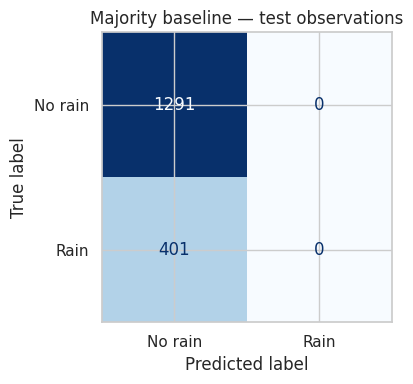

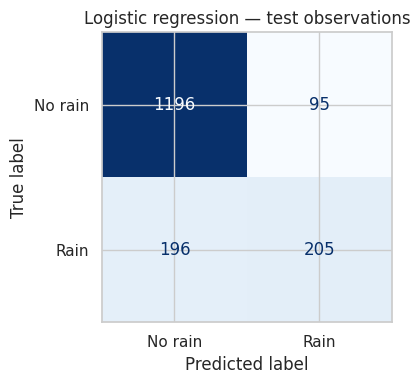

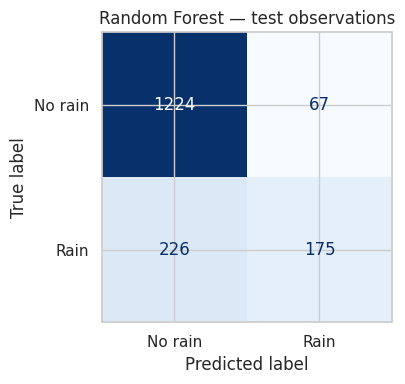

              precision    recall  f1-score   support

     No rain       0.86      0.93      0.89      1291
        Rain       0.68      0.51      0.58       401

    accuracy                           0.83      1692
   macro avg       0.77      0.72      0.74      1692
weighted avg       0.82      0.83      0.82      1692



In [39]:
# Show the classification errors for every evaluated model.
for model_name, predictions in test_predictions_by_model.items():
    fig, ax = plt.subplots(figsize=(5, 4))

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions,
        labels=[0, 1],
        display_labels=["No rain", "Rain"],
        cmap="Blues",
        values_format="d",
        colorbar=False,
        ax=ax
    )

    ax.set_title(f"{model_name} — test observations")
    plt.tight_layout()
    plt.show()

# Report class-specific performance for the selected model.
print(classification_report(
    y_test,
    test_predictions_by_model[selected_model_name],
    labels=[0, 1],
    target_names=["No rain", "Rain"],
    zero_division=0
))

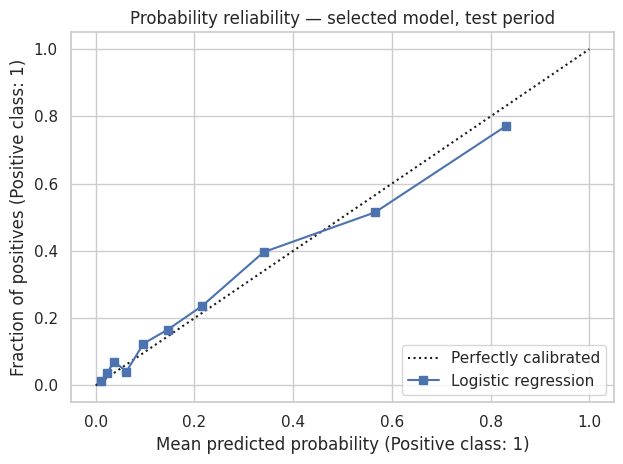

In [40]:
from sklearn.calibration import CalibrationDisplay

# Compare estimated probabilities with observed rain frequencies.
CalibrationDisplay.from_predictions(
    y_test,
    test_probabilities_by_model[selected_model_name],
    n_bins=10,
    strategy="quantile",
    name=selected_model_name
)

plt.title("Probability reliability — selected model, test period")
plt.tight_layout()
plt.show()

In [41]:
# Keep the original observation identifiers and actual outcomes.
prediction_audit = test_df[
    ["Date", "Location", "RainTomorrow"]
].copy()

prediction_audit["SourceRow"] = prediction_audit.index
prediction_audit["TargetDate"] = (
    prediction_audit["Date"] + pd.Timedelta(days=1)
)

prediction_audit["RainProbability"] = (
    test_probabilities_by_model[selected_model_name]
)

# Convert predicted classes back into readable target labels.
prediction_audit["PredictedRain"] = pd.Series(
    test_predictions_by_model[selected_model_name],
    index=prediction_audit.index
).map({0: "No", 1: "Yes"})

prediction_audit["Correct"] = (
    prediction_audit["PredictedRain"]
    == prediction_audit["RainTomorrow"]
)

display(prediction_audit.head(10).round(3))

# Inspect a few errors while preserving the complete audit table.
display(
    prediction_audit.loc[~prediction_audit["Correct"]]
    .head(10)
    .round(3)
)

,Date,Location,RainTomorrow,SourceRow,TargetDate,RainProbability,PredictedRain,Correct
66561,2015-09-26,MelbourneAirport,No,66561,2015-09-27,0.016,No,True
80359,2015-09-26,Watsonia,No,80359,2015-09-27,0.015,No,True
66562,2015-09-27,MelbourneAirport,No,66562,2015-09-28,0.006,No,True
80360,2015-09-27,Watsonia,No,80360,2015-09-28,0.015,No,True
66563,2015-09-28,MelbourneAirport,No,66563,2015-09-29,0.213,No,True
80361,2015-09-28,Watsonia,No,80361,2015-09-29,0.236,No,True
66564,2015-09-29,MelbourneAirport,No,66564,2015-09-30,0.102,No,True
80362,2015-09-29,Watsonia,No,80362,2015-09-30,0.189,No,True
66565,2015-09-30,MelbourneAirport,No,66565,2015-10-01,0.026,No,True
80363,2015-09-30,Watsonia,No,80363,2015-10-01,0.034,No,True


,Date,Location,RainTomorrow,SourceRow,TargetDate,RainProbability,PredictedRain,Correct
66575,2015-10-10,MelbourneAirport,Yes,66575,2015-10-11,0.084,No,False
80373,2015-10-10,Watsonia,Yes,80373,2015-10-11,0.091,No,False
66576,2015-10-11,MelbourneAirport,Yes,66576,2015-10-12,0.241,No,False
80374,2015-10-11,Watsonia,Yes,80374,2015-10-12,0.489,No,False
66585,2015-10-20,MelbourneAirport,Yes,66585,2015-10-21,0.205,No,False
80383,2015-10-20,Watsonia,Yes,80383,2015-10-21,0.319,No,False
66587,2015-10-22,MelbourneAirport,No,66587,2015-10-23,0.799,Yes,False
66595,2015-10-30,MelbourneAirport,Yes,66595,2015-10-31,0.031,No,False
80394,2015-10-31,Watsonia,Yes,80394,2015-11-01,0.394,No,False
66597,2015-11-01,MelbourneAirport,No,66597,2015-11-02,0.687,Yes,False


## 10. Results, limitations, and reproducibility

We summarize the selected model's performance on the reserved
test period and compare it with the majority-class baseline.

Our conclusions apply to the evaluated historical observations
from Melbourne, Melbourne Airport, and Watsonia.

We preserve metrics, individual predictions, exclusion records,
and configuration details for review.

In [42]:
from sklearn.metrics import confusion_matrix
from IPython.display import Markdown, display

# Retrieve the results of the model selected through validation.
selected_metrics = test_results.loc[selected_model_name]
baseline_metrics = test_results.loc["Majority baseline"]

# Count each type of classification outcome.
tn, fp, fn, tp = confusion_matrix(
    y_test,
    test_predictions_by_model[selected_model_name],
    labels=[0, 1]
).ravel()

# Compare ranking performance with the baseline.
ap_difference = (
    selected_metrics["Average precision"]
    - baseline_metrics["Average precision"]
)

# Generate a report using actual results, without invented numbers.
results_summary = f"""
## Results

The model selected through chronological cross-validation was
**{selected_model_name}**.

It was evaluated on **{len(test_df):,} station observations**,
with observation dates from **{test_df["Date"].min().date()}**
to **{test_df["Date"].max().date()}**.

### Classification performance
- Accuracy: **{selected_metrics["Accuracy"]:.1%}**
- Rain precision: **{selected_metrics["Precision"]:.1%}**
- Rain recall: **{selected_metrics["Recall"]:.1%}**
- F1 score: **{selected_metrics["F1"]:.3f}**

### Probability performance
- Average precision: **{selected_metrics["Average precision"]:.3f}**
- ROC AUC: **{selected_metrics["ROC AUC"]:.3f}**
- Brier score: **{selected_metrics["Brier score"]:.3f}**

The majority baseline achieved accuracy of
**{baseline_metrics["Accuracy"]:.1%}** and average precision of
**{baseline_metrics["Average precision"]:.3f}**.

The selected model's average precision minus the baseline's was
**{ap_difference:+.3f}**.

### Classification outcomes
- Correct no-rain predictions: **{tn:,}**
- False rain alarms: **{fp:,}**
- Missed rain observations: **{fn:,}**
- Correct rain detections: **{tp:,}**

### Limitations
- Results describe historical data from three selected stations.
- Station observations are not counts of unique rainy days.
- Performance in other regions or future periods requires evaluation.
- Operational use requires checking when each weather measurement
  becomes available.
- Probability ranking performance does not establish calibration;
  the reliability plot must also be examined.
- Further model or threshold adjustments require training-period
  validation or a new independent evaluation set.

### Acknowledgment
This educational project builds on the final assignment from IBM's
Machine Learning with Python course on Coursera.
"""

display(Markdown(results_summary))


## Results

The model selected through chronological cross-validation was
**Logistic regression**.

It was evaluated on **1,692 station observations**,
with observation dates from **2015-09-26**
to **2017-06-25**.

### Classification performance
- Accuracy: **82.8%**
- Rain precision: **68.3%**
- Rain recall: **51.1%**
- F1 score: **0.585**

### Probability performance
- Average precision: **0.668**
- ROC AUC: **0.850**
- Brier score: **0.123**

The majority baseline achieved accuracy of
**76.3%** and average precision of
**0.237**.

The selected model's average precision minus the baseline's was
**+0.431**.

### Classification outcomes
- Correct no-rain predictions: **1,196**
- False rain alarms: **95**
- Missed rain observations: **196**
- Correct rain detections: **205**

### Limitations
- Results describe historical data from three selected stations.
- Station observations are not counts of unique rainy days.
- Performance in other regions or future periods requires evaluation.
- Operational use requires checking when each weather measurement
  becomes available.
- Probability ranking performance does not establish calibration;
  the reliability plot must also be examined.
- Further model or threshold adjustments require training-period
  validation or a new independent evaluation set.

### Acknowledgment
This educational project builds on the final assignment from IBM's
Machine Learning with Python course on Coursera.
